## Imports

In [ ]:
pip install ultralytics

In [2]:
!pip install -q kaggle

In [3]:
import os
import glob
import yaml
import shutil
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive, files

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
# 1. Upload kaggle.json token
from google.colab import files
files.upload()

# 2. Configure Kaggle credentials directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


### Dataset and model training

In [5]:
# Download dataset
!kaggle datasets download -d mahmoudeldebase/egyptian-cars-plates --unzip -p ./raw_dataset

# Locate image/label folders (searched recursively since the extracted
# folder structure/depth isn't guaranteed to be consistent across dataset versions)
img_folders = glob.glob("./raw_dataset/**/Vehicles", recursive=True)
label_folders = glob.glob("./raw_dataset/**/Vehicles Labeling", recursive=True)

if not img_folders or not label_folders:
    raise FileNotFoundError("Could not find 'Vehicles' or 'Vehicles Labeling' directories.")

img_dir = img_folders[0]
label_dir = label_folders[0]

print(f"Images: {img_dir}")
print(f"Labels: {label_dir}")

# NOTE: on a case-sensitive filesystem (Colab/Linux) this is fine, but listing
# both '*.jpg' and '*.JPG' etc. would double-count matches on a case-insensitive
# filesystem (e.g. default macOS/Windows). Not an issue here, but worth knowing
# if this is ever run outside Colab.
img_extensions = ('*.jpg', '*.png', '*.jpeg', '*.JPG', '*.PNG')
all_images = []
for ext in img_extensions:
    all_images.extend(glob.glob(os.path.join(img_dir, ext)))

matched_pairs = []
for img_path in all_images:
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    txt_path = os.path.join(label_dir, f"{base_name}.txt")
    if os.path.exists(txt_path):
        matched_pairs.append((img_path, txt_path))

print(f"Matched {len(matched_pairs)} image-label pairs")

if len(matched_pairs) == 0:
    raise ValueError("No matching image-label pairs found. Check file naming.")

# 70/15/15 train/val/test split
yolo_dir = os.path.abspath("./yolo_dataset")
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)

train_pairs, temp_pairs = train_test_split(matched_pairs, test_size=0.30, random_state=42)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.50, random_state=42)

def copy_pairs(pairs, split):
    for img_p, txt_p in pairs:
        filename = os.path.basename(img_p)
        txt_name = os.path.basename(txt_p)
        shutil.copy(img_p, os.path.join(yolo_dir, "images", split, filename))
        shutil.copy(txt_p, os.path.join(yolo_dir, "labels", split, txt_name))

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs, 'val')
copy_pairs(test_pairs, 'test')

yaml_path = os.path.join(yolo_dir, "data.yaml")
yaml_data = {
    'path': yolo_dir,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {0: 'license_plate'}
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f)

print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# NOTE: exist_ok=True means a re-run with the same project/name will overwrite
# results from a previous training run in that folder rather than erroring or
# incrementing (e.g. yolov8_ealpr2) — fine for iterating, but worth remembering
# if you want to keep old runs for comparison.
model = YOLO("yolov8n.pt")
model.train(
    data=yaml_path,
    epochs=25,        # NOTE: fairly low epoch count for training from a COCO-pretrained
                       # checkpoint on a single-class task — reasonable as a first pass,
                       # but check the loss/mAP curves for whether it's still improving
                       # at epoch 25 before trusting this as the final model.
    imgsz=640,
    batch=128,         # NOTE: batch=128 at imgsz=640 is memory-heavy — this will OOM on
                       # smaller GPUs. Drop to 16-32 if training
                       # crashes, or leave batch=-1 to let Ultralytics auto-size it to your GPU.
    project="egypt_plate_detector",
    name="yolov8_ealpr",
    exist_ok=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    flipud=0.0,        # plates don't appear upside-down
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
)

Dataset URL: https://www.kaggle.com/datasets/mahmoudeldebase/egyptian-cars-plates
License(s): apache-2.0
100% 196M/196M [00:12<00:00, 16.8MB/s]

Found Images at: ./raw_dataset/EALPR Vechicles dataset/Vehicles
Found Labels at: ./raw_dataset/EALPR Vechicles dataset/Vehicles Labeling
Successfully matched 2087 image-label pairs!
Dataset configured with Train (1460), Val (313), and Test (314) sets!
Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynam

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f921cf3dda0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Loaded YOLOv8 model successfully from: /content/runs/detect/egypt_plate_detector/yolov8_ealpr/weights/best.pt


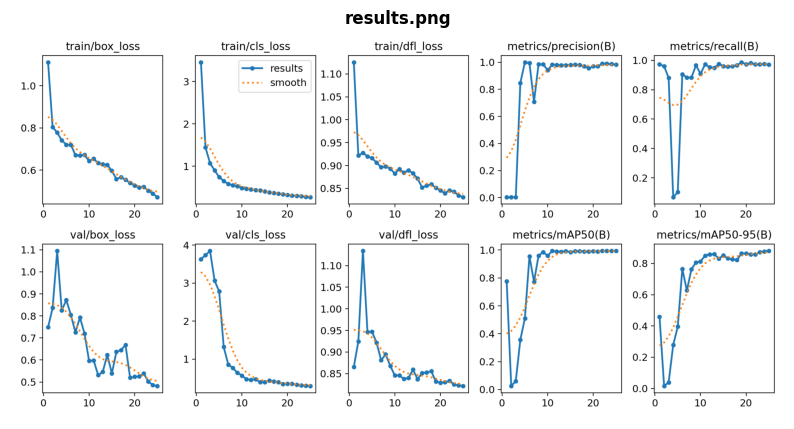

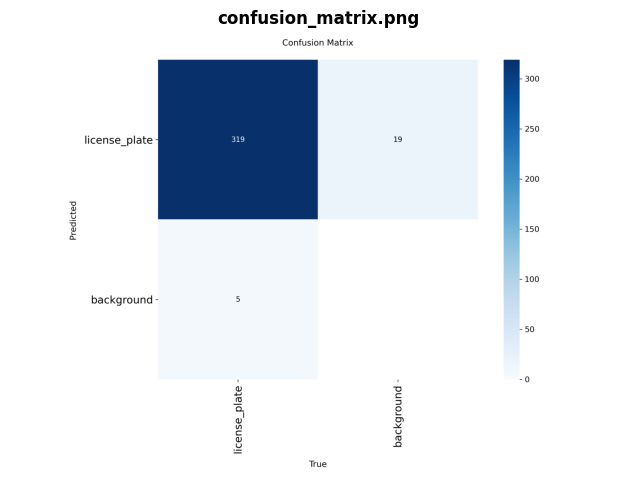

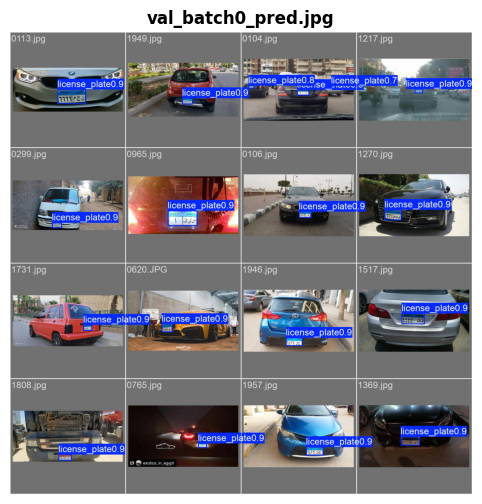


image 1/1 /content/yolo_dataset/images/val/0130.jpg: 480x640 1 license_plate, 7.0ms
Speed: 1.8ms preprocess, 7.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


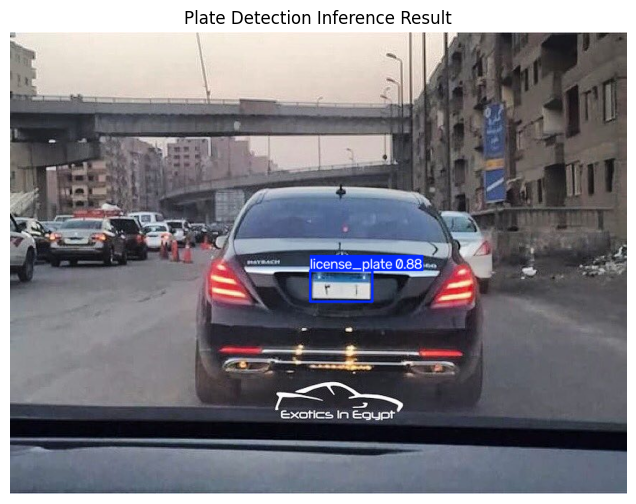

In [6]:
model_path = "/content/runs/detect/egypt_plate_detector/yolov8_ealpr/weights/best.pt"
model = YOLO(model_path)
print(f"Loaded model from: {model_path}")
run_dir = "/content/runs/detect/egypt_plate_detector/yolov8_ealpr"
plot_files = ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]

for file_name in plot_files:
    file_path = os.path.join(run_dir, file_name)
    if os.path.exists(file_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(file_path)
        plt.imshow(img)
        plt.axis("off")
        plt.title(file_name, fontsize=12, fontweight='bold')
        plt.show()

# NOTE: this always tests on val_images[0] — the same single image every time
# this cell runs. Fine for a quick sanity check, but it's not representative
# of overall model performance and won't catch failures on other images. Worth
# looping over a handful of val images (or picking one at random) if you want
# a better sense of how the model generalizes.
val_images = glob.glob("/content/yolo_dataset/images/val/*.jpg") + \
             glob.glob("/content/yolo_dataset/images/val/*.png")

if val_images:
    test_img_path = val_images[0]

    # NOTE: conf=0.5 here is stricter than the conf=0.15 used in the inference
    # script — a plate that shows up fine at 0.15 there may not get detected at
    # all in this validation check. Worth keeping consistent, or being intentional
    # about why validation uses a higher bar than production inference.
    results = model(test_img_path, conf=0.5)[0]

    annotated_img = results.plot()
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Plate Detection Inference Result")
    plt.show()
else:
    print("No validation images found — skipping inference check.")

In [7]:
model = YOLO("/content/runs/detect/egypt_plate_detector/yolov8_ealpr/weights/best.pt")

metrics = model.val(
    data="/content/yolo_dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
)

print("\n--- TEST SET METRICS ---")
print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall   : {metrics.box.mr:.4f}")

Ultralytics 8.4.144 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2420.7±1184.3 MB/s, size: 112.1 KB)
val: Scanning /content/yolo_dataset/labels/test... 314 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 314/314 1.6Kit/s 0.2s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 8.2it/s 2.4s
                   all        314        325      0.993      0.994      0.992      0.887
Speed: 0.9ms preprocess, 2.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val

--- TEST SET METRICS ---
mAP50-95 : 0.8869
mAP50    : 0.9923
Precision: 0.9930
Recall   : 0.9938


## OCR & Plate type identification

In [8]:
!pip install paddlepaddle paddleocr ultralytics opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7

In [24]:
"""Egyptian license plate detection + OCR pipeline.

YOLOv8 locates the plate, classical CV preprocessing (denoise -> Otsu
threshold -> light dilation) prepares the crop, and PaddleOCR reads the
result. Plate type (Private/Taxi/Commercial/etc.) is inferred from the
header color band.
"""

import os
import glob
import cv2
import json
import re
import logging
import numpy as np
from ultralytics import YOLO

os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"

from paddleocr import PaddleOCR

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

MODEL_PATH = os.environ.get(
    "PLATE_MODEL_PATH",
    "/content/runs/detect/egypt_plate_detector/yolov8_ealpr/weights/best.pt",
)
TEST_IMG_DIR = os.environ.get("PLATE_TEST_IMG_DIR", "/content/yolo_dataset/images/test")
MIN_OCR_CONFIDENCE = float(os.environ.get("PLATE_MIN_OCR_CONF", "0.5"))

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

# Maps Arabic-Indic (Eastern Arabic) and Extended Arabic-Indic (Persian) digits to Western 0-9
ARABIC_DIGIT_MAP = {
    '\u0660': '0', '\u0661': '1', '\u0662': '2', '\u0663': '3', '\u0664': '4',
    '\u0665': '5', '\u0666': '6', '\u0667': '7', '\u0668': '8', '\u0669': '9',
    '\u06F0': '0', '\u06F1': '1', '\u06F2': '2', '\u06F3': '3', '\u06F4': '4',
    '\u06F5': '5', '\u06F6': '6', '\u06F7': '7', '\u06F8': '8', '\u06F9': '9',
}

PLATE_TYPE_COLOR_RANGES = {
    "Private (Light Blue)": [(np.array([85, 50, 100]), np.array([125, 255, 255]))],
    "Taxi (Orange)": [(np.array([5, 100, 100]), np.array([22, 255, 255]))],
    "Commercial (Yellow)": [(np.array([23, 80, 100]), np.array([35, 255, 255]))],
    "Government (Dark Blue)": [(np.array([126, 80, 50]), np.array([140, 255, 220]))],
    "Diplomatic (Green)": [(np.array([36, 50, 50]), np.array([84, 255, 255]))],
}


def detect_egyptian_plate_type(crop_bgr):
    """Analyzes the top 25% header region of a plate crop to determine vehicle category."""
    if crop_bgr is None or crop_bgr.size == 0:
        return "Unknown"

    h, w = crop_bgr.shape[:2]
    if h == 0 or w == 0:
        return "Unknown"

    header = crop_bgr[0:int(h * 0.25), 0:w]
    if header.size == 0:
        return "Unknown"

    hsv = cv2.cvtColor(header, cv2.COLOR_BGR2HSV)
    total_header_pixels = header.shape[0] * header.shape[1]
    scores = {}

    for category, ranges in PLATE_TYPE_COLOR_RANGES.items():
        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
        for lower, upper in ranges:
            mask |= cv2.inRange(hsv, lower, upper)
        scores[category] = cv2.countNonZero(mask)

    detected_type = max(scores, key=scores.get)
    max_pixels = scores[detected_type]
    logger.debug("Plate type pixel scores: %s", scores)

    if (max_pixels / float(total_header_pixels)) < 0.15:
        return "Unknown / Unclear"

    return detected_type


def fix_plate_for_ocr(crop_bgr):
    """Strips the top 30% header ('EGYPT / مصر') and resizes to a standard height."""
    h, w = crop_bgr.shape[:2]
    crop_body = crop_bgr[int(h * 0.30):h, 0:w]

    h_b, w_b = crop_body.shape[:2]
    if h_b == 0 or w_b == 0:
        return crop_bgr

    target_h = 240
    target_w = max(1, int(target_h * (w_b / float(h_b))))
    return cv2.resize(crop_body, (target_w, target_h), interpolation=cv2.INTER_CUBIC)


def preprocess_plate_classical(crop_bgr):
    """Denoise -> grayscale -> Otsu threshold -> light stroke-reconnecting
    dilation -> invert. Otsu adapts the threshold to each image's own
    brightness instead of a fixed cutoff; erosion is skipped since it
    fragmented thin plate-font strokes into disconnected dots."""
    denoised = cv2.fastNlMeansDenoisingColored(
        crop_bgr, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21
    )
    gray = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)

    _, threshold_image = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((2, 2), np.uint8)
    inv = cv2.bitwise_not(threshold_image)
    dilated = cv2.dilate(inv, kernel, iterations=1)
    thickened = cv2.bitwise_not(dilated)
    final = cv2.bitwise_not(thickened)

    return cv2.cvtColor(final, cv2.COLOR_GRAY2BGR)


def extract_raw_text_from_ocr(ocr_res, min_confidence=MIN_OCR_CONFIDENCE):
    """Extracts raw string output + average confidence from PaddleOCR predictions,
    filtering out tokens below min_confidence."""
    all_texts = []
    all_scores = []

    for result in ocr_res:
        if not hasattr(result, "json"):
            continue

        result_dict = result.json
        if isinstance(result_dict, str):
            result_dict = json.loads(result_dict)

        res = result_dict.get("res", result_dict)
        texts = res.get("rec_texts", [])
        scores = res.get("rec_scores", [1.0] * len(texts))

        for text, score in zip(texts, scores):
            if score >= min_confidence:
                all_texts.append(text)
                all_scores.append(score)
            else:
                logger.debug("Dropped low-confidence OCR token '%s' (%.2f)", text, score)

    raw_text = " ".join(all_texts)
    avg_confidence = float(np.mean(all_scores)) if all_scores else 0.0
    return raw_text, avg_confidence


def normalize_arabic_digits(digit_str):
    """Converts Arabic-Indic / Extended Arabic-Indic digits to Western 0-9."""
    return "".join(ARABIC_DIGIT_MAP.get(ch, ch) for ch in digit_str)


def clean_egyptian_plate_text(text):
    """Filters noise and splits Arabic letters and numbers."""
    cleaned = re.sub(r'[a-zA-Z!|_\-\[\]\{\}]', '', text)

    digits_raw = "".join(re.findall(r'[\u0660-\u0669\u06F0-\u06F90-9]', cleaned))
    digits = normalize_arabic_digits(digits_raw)
    letters = "".join(re.findall(r'[\u0621-\u064A]', cleaned))

    formatted = f"{letters} | {digits}" if letters and digits else cleaned.strip()
    return {
        "raw": text.strip(),
        "letters": letters,
        "digits": digits,
        "digits_original": digits_raw,
        "formatted": formatted,
    }


def collect_test_images(test_dir, extensions=VALID_EXTENSIONS):
    """Case-insensitively collects images from a directory, sorted for reproducible indexing."""
    images = [
        p for p in glob.glob(os.path.join(test_dir, "*"))
        if p.lower().endswith(extensions)
    ]
    return sorted(images)


def load_models(model_path=MODEL_PATH):
    yolo_model = YOLO(model_path)
    ocr_engine = PaddleOCR(
        use_textline_orientation=False,
        lang="ar",
        enable_mkldnn=False,
    )
    return yolo_model, ocr_engine


def process_image(image_bgr, yolo_model, ocr_engine, conf_threshold=0.15):
    """Runs detection + OCR on an already-loaded BGR image array and returns
    a list of result dicts. Accepts an array directly (rather than a path)
    so it works equally well with uploaded images and files on disk."""
    if image_bgr is None:
        logger.warning("Received an empty image array")
        return []

    results = yolo_model(image_bgr, conf=conf_threshold, verbose=False)[0]
    if len(results.boxes) == 0:
        logger.info("No license plate detected by YOLO in this image.")
        return []

    h_img, w_img = image_bgr.shape[:2]
    detections = []

    for idx, box in enumerate(results.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

        x1, y1 = max(0, x1 - 5), max(0, y1 - 5)
        x2, y2 = min(w_img, x2 + 5), min(h_img, y2 + 5)

        if x2 <= x1 or y2 <= y1:
            logger.warning("Skipping detection #%d: invalid box after padding/clamping", idx + 1)
            continue

        crop = image_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            logger.warning("Skipping detection #%d: empty crop", idx + 1)
            continue

        plate_type = detect_egyptian_plate_type(crop)
        resized_crop = fix_plate_for_ocr(crop)
        classical_processed = preprocess_plate_classical(resized_crop)

        ocr_res = ocr_engine.predict(classical_processed)
        raw_text, confidence = extract_raw_text_from_ocr(ocr_res)
        parsed = clean_egyptian_plate_text(raw_text)

        detections.append({
            "index": idx + 1,
            "box": (x1, y1, x2, y2),
            "plate_type": plate_type,
            "confidence": confidence,
            "parsed": parsed,
            "resized_crop": resized_crop,
            "processed_crop": classical_processed,
        })

    return detections

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('arabic_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/arabic_PP-OCRv5_mobile_rec`.


--- Detection #1 ---
Plate Type : Unknown / Unclear
OCR Conf.  : 0.79
Raw Output : ١١١١١ ن سر
Letters    : نسر
Digits     : 11111
Formatted  : نسر | 11111



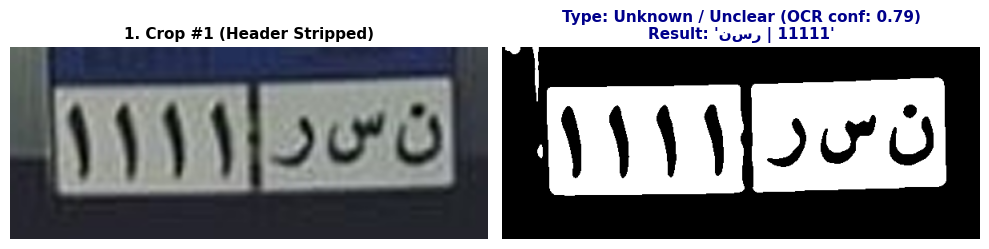

In [28]:
test_images = collect_test_images(TEST_IMG_DIR)
if not test_images:
    raise FileNotFoundError(f"No test images found inside {TEST_IMG_DIR}")

if IMAGE_INDEX >= len(test_images):
    raise IndexError(
        f"IMAGE_INDEX={IMAGE_INDEX} out of range; only {len(test_images)} test images found."
    )

img_path = test_images[22]
logger.info("Processing test image: %s", os.path.basename(img_path))

yolo_model, ocr_engine = load_models(MODEL_PATH)
detections = process_image(image_bgr, yolo_model, ocr_engine)

for detection in detections:
    parsed = detection["parsed"]
    print(f"--- Detection #{detection['index']} ---")
    print(f"Plate Type : {detection['plate_type']}")
    print(f"OCR Conf.  : {detection['confidence']:.2f}")
    print(f"Raw Output : {parsed['raw']}")
    print(f"Letters    : {parsed['letters']}")
    print(f"Digits     : {parsed['digits']}")
    print(f"Formatted  : {parsed['formatted']}\n")

    show_detection(detection)